In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## First Inspection
- Data Visualisation 
- Dataset Loading



In [5]:
sns.set_theme(style="whitegrid")

In [7]:
data = pd.read_csv("../data/processed/final_dataset.csv")

In [8]:
print(data.head())
print("\nShape:", data.shape)
print("\nColumns:")
print(data.columns)
print("\nInfo:")
print(data.info())
print("\nMissing values:")
print(data.isna().sum())

            id            created_at  width  height  likes    color  \
0  IicyiaPYGGI  2016-06-05T17:07:21Z   4928    3264  10099  #f3f3f3   
1  EwKXn5CapA4  2018-02-13T04:33:34Z   3648    5472  16755  #26260c   
2  1Z2niiBPg5A  2016-08-01T17:13:04Z   7372    4392   5795  #404040   
3  UCd78vfC8vU  2016-08-28T15:26:50Z   3634    5998   4613  #d9f3f3   
4  cssvEZacHvQ  2015-05-31T15:42:52Z   4000    6000   4248  #405926   

                                     alt_description       username  \
0                                     orange flowers       henry_be   
1        sun light passing through green leafed tree   jeremybishop   
2                              foggy mountain summit          v2osk   
3           two brown deer beside trees and mountain   thejoltjoker   
4  gray concrete bridge and waterfalls during day...  blakeverdoorn   

                                           image_url  brightness    sharpness  
0  https://images.unsplash.com/photo-146514634442...  208.808395  

## First Engagement Analysis (likes)

In [9]:
print("\nSummary statistics for likes:")
print(data["likes"].describe())


Summary statistics for likes:
count     1006.000000
mean      2498.759443
std       2550.429328
min          0.000000
25%        810.500000
50%       1749.500000
75%       3387.000000
max      19493.000000
Name: likes, dtype: float64


#### Engagement Distribution Visualization

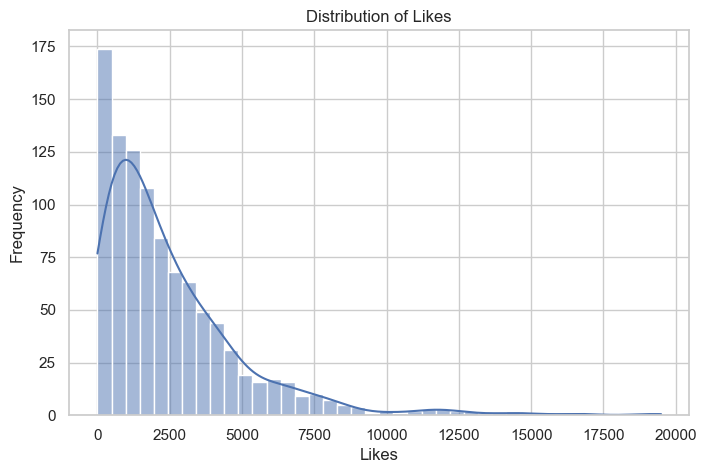

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data["likes"], bins=40, kde=True)
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()

#### Adjustment to the log transformation

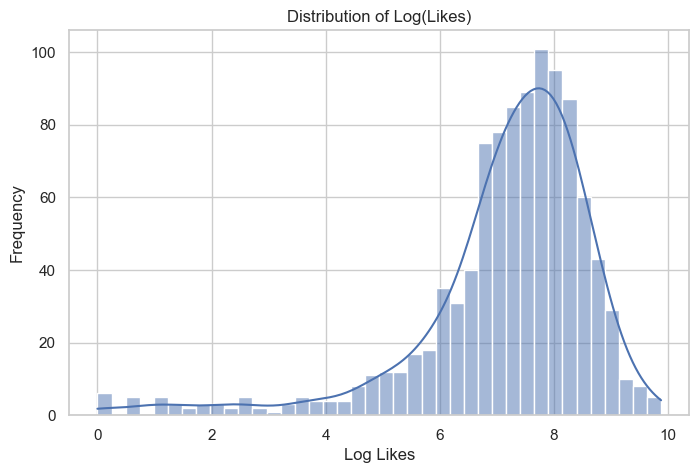

In [11]:
data["log_likes"] = np.log1p(data["likes"])

plt.figure(figsize=(8,5))
sns.histplot(data["log_likes"], bins=40, kde=True)
plt.title("Distribution of Log(Likes)")
plt.xlabel("Log Likes")
plt.ylabel("Frequency")
plt.show()

## Features Analysis

In [12]:
features = ["brightness", "sharpness", "width", "height"]
print(data[features].describe())

        brightness     sharpness        width        height
count  1006.000000   1006.000000  1006.000000   1006.000000
mean    108.797560    876.361001  4482.385686   3919.869781
std      45.950482   1254.770640  1429.440844   1295.141145
min      14.353251      2.155268  1438.000000   1218.000000
25%      76.086302    116.471036  3437.250000   3071.250000
50%     107.305622    399.897226  4272.000000   3744.000000
75%     135.750336   1152.450318  5472.000000   4634.500000
max     250.589340  11482.932958  9504.000000  12247.000000


#### Brightness Distribution

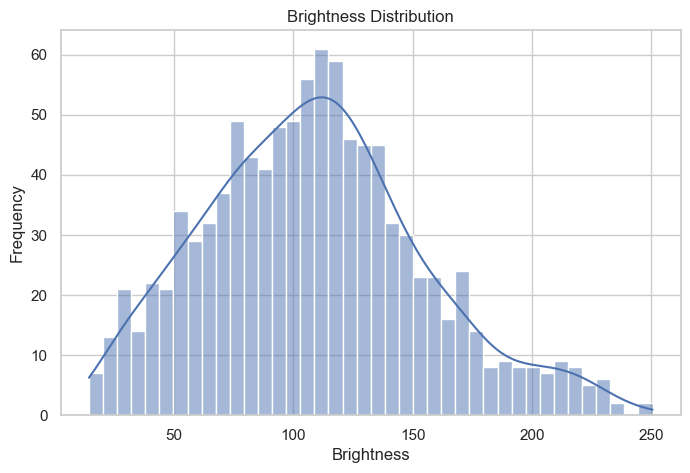

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data["brightness"], bins=40, kde=True)

plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")

plt.show()

#### Sharpness Distribution

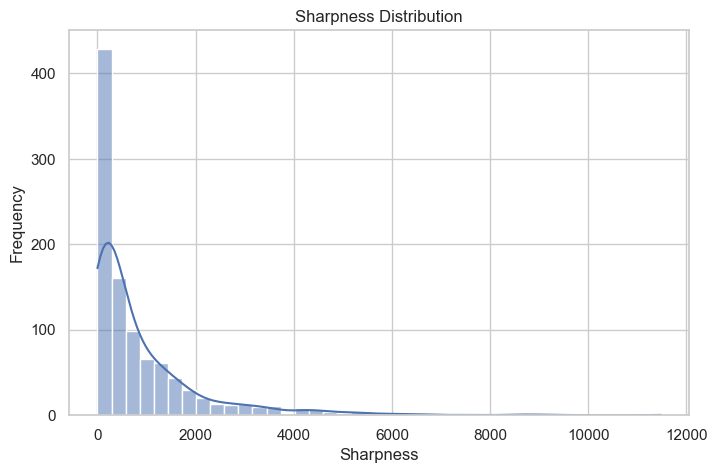

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data["sharpness"], bins=40, kde=True)

plt.title("Sharpness Distribution")
plt.xlabel("Sharpness")
plt.ylabel("Frequency")

plt.show()


#### Dimensions Distribution

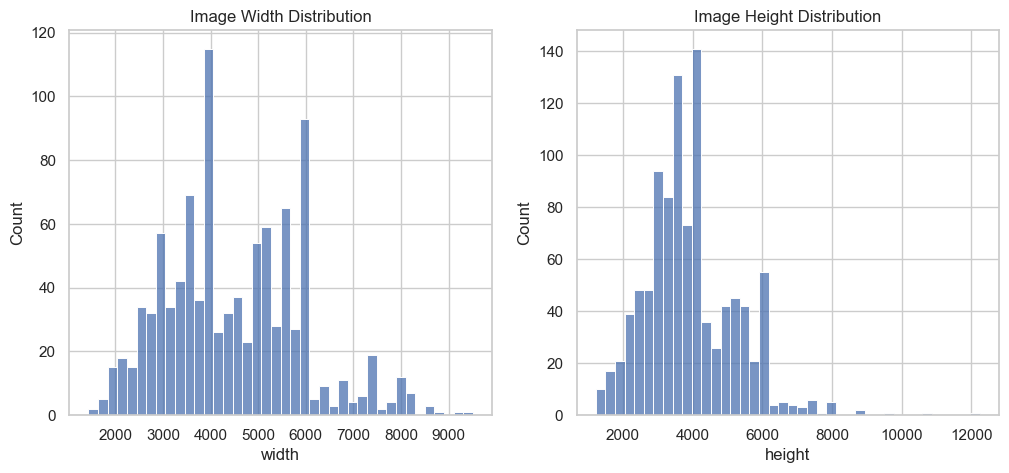

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(data["width"], bins=40, ax=axes[0])
axes[0].set_title("Image Width Distribution")

sns.histplot(data["height"], bins=40, ax=axes[1])
axes[1].set_title("Image Height Distribution")

plt.show()


#### Orientation Distribution

In [16]:
data["aspect_ratio"] = data["width"] / data["height"]

data["orientation"] = np.where(
    data["height"] > data["width"],
    "portrait",
    np.where(data["width"] > data["height"], "landscape", "square")
)

print(data["orientation"].value_counts())



orientation
landscape    649
portrait     344
square        13
Name: count, dtype: int64
